In [28]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *

In [29]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import MarginalLpModel, PermutationLpModel

In [30]:
def verify_lp_winners(voter_positions, candidates, strategies, winners):
    """Check that voters generated by the LP actually elect the target winners."""
    lp_positions = voter_positions[
        ~np.isnan(voter_positions[:, 0])
    ]  # drop NaN rows (rankings not realizable in 2D)
    lp_voters = [Voter(position=p) for p in lp_positions]
    lp_result = Election(candidates=candidates, voters=lp_voters).compare_strategies(
        strategies=strategies
    )

    print(f"voters: {len(lp_voters)}\n")
    print(f"{'rule':<12} {'target':>7} {'actual':>7}  ok")
    all_ok = True
    for s in strategies:
        target_idx = winners[s.key]
        actual_idx = candidates.index(lp_result.winner(s))
        ok = target_idx == actual_idx
        all_ok &= ok
        print(f"{s.key:<12} {target_idx:>7} {actual_idx:>7}  {'OK' if ok else 'X'}")

    assert all_ok, "LP model does NOT reproduce the target winners!"
    print("\nAll winners match — LP model is correct.")

In [31]:
N_VOTERS = 100
N_CANDIDATES = 3

In [32]:
# # winners = {
# #     "plurality": idxs[0],
# #     "borda": idxs[1]
# # }

# for _ in range(100):
#     candidates = [Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)]
#     idxs = find_farthest_triple([candidate.position for candidate in candidates])
#     winners = {
#         "plurality": random.randint(0, len(candidates) - 1),
#         "borda": random.randint(0, len(candidates) - 1),
#         "veto": random.randint(0, len(candidates) - 1)
#     }

#     model = PermutationLpModel(
#         candidates=candidates,
#         n_voters = N_VOTERS,
#         winners=winners
#     )

#     if model.solve() == 'Optimal': break

# model.solve()

In [33]:
# candidates = [
#     Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
# ]

# idxs = find_farthest_triple([candidate.position for candidate in candidates])

# winners = {
#     "plurality": random.randint(0, len(candidates) - 1),
#     "borda": random.randint(0, len(candidates) - 1),
#     "veto": random.randint(0, len(candidates) - 1),
# }

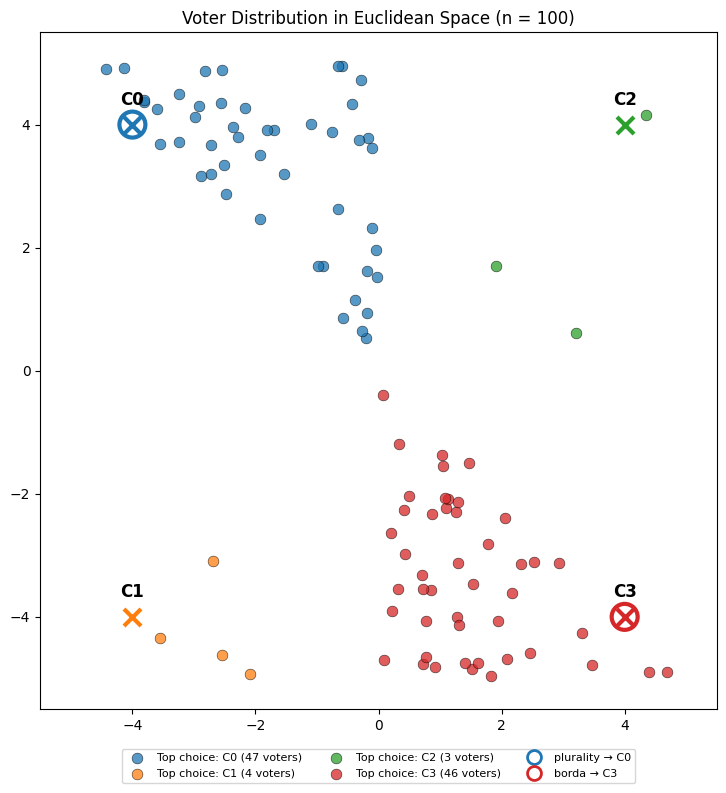

In [34]:
positions = [(-4, 4), (-4, -4), (4, 4), (4, -4)]
candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

idxs = find_farthest_pair([candidate.position for candidate in candidates])

winners = {
    "plurality": 0,
    "borda": 3,
}

model = PermutationLpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
model_result = model.solve()
assert model_result == "Optimal"

plot_lp_result(candidates, model.generate_voter_positions(), winners)

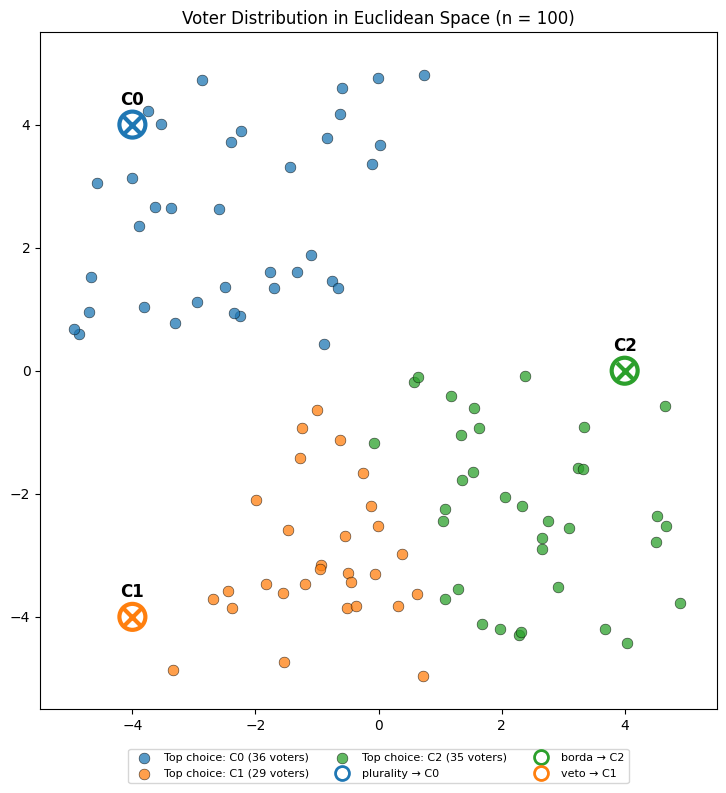

In [35]:
positions = [
    (-4, 4),
    (-4, -4),
    (4, 0),
]
candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

winners = {"plurality": 0, "borda": 2, "veto": 1}

model = PermutationLpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
model_result = model.solve()
assert model_result == "Optimal"

plot_lp_result(candidates, model.generate_voter_positions(), winners)

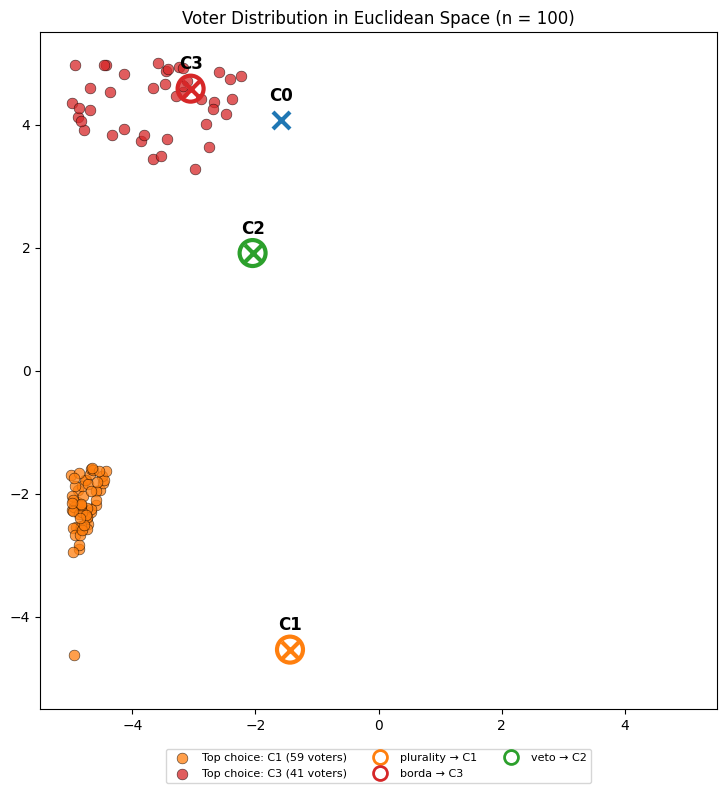

In [36]:
N_VOTERS = 100
N_CANDIDATES = 4

candidates = [
    Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
]

idxs = find_farthest_triple([candidate.position for candidate in candidates])

winners = {
    "plurality": random.randint(0, len(candidates) - 1),
    "borda": random.randint(0, len(candidates) - 1),
    "veto": random.randint(0, len(candidates) - 1),
}

model = PermutationLpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
model_result = model.solve()
assert model_result == "Optimal"

plot_lp_result(candidates, model.generate_voter_positions(), winners)

# 3.


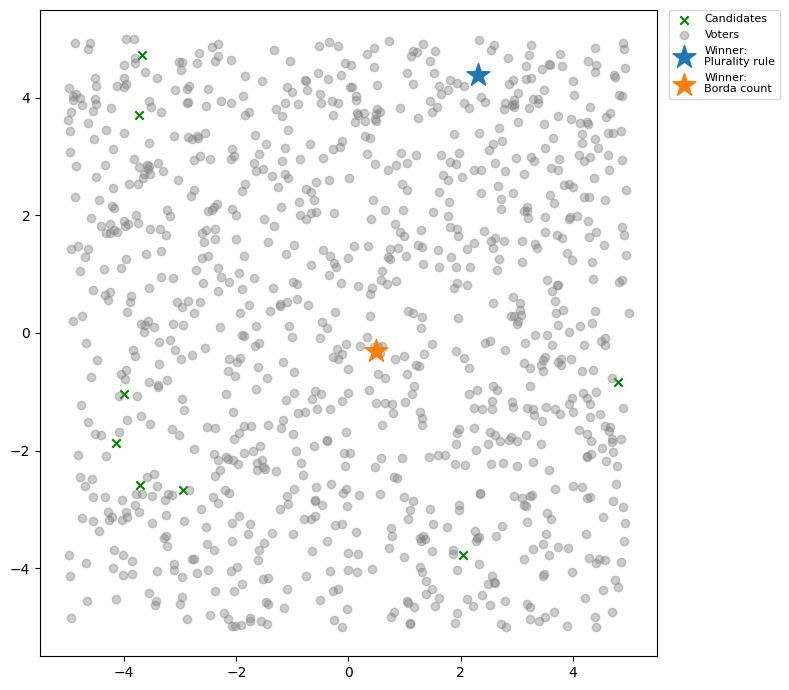

In [37]:
N_VOTERS = 1000
N_CANDIDATES = 10

# strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]
strategies = [PluralityStrategy(), BordaCountStrategy()]

# Resample the election until every rule has a unique (non-tied) winner.
# A tie means margin 0 -> the LP cannot enforce a strict win, so we reject such
# cases up front. This guarantees a witness exists and the LP below returns Optimal.
while True:
    candidates = [
        Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
    ]
    voters = [Voter(position=random_2d_point()) for _ in range(N_VOTERS)]
    election = Election(candidates=candidates, voters=voters)
    election_result = election.compare_strategies(strategies=strategies)
    if not any(tally.is_tie() for tally in election_result.tallies.values()):
        break

plot_results(election_result)

In [38]:
# print(election_result.tallies[PluralityStrategy().name])
# print(election_result.tallies[BordaCountStrategy().name])
# print(election_result.tallies[VetoStrategy().name])

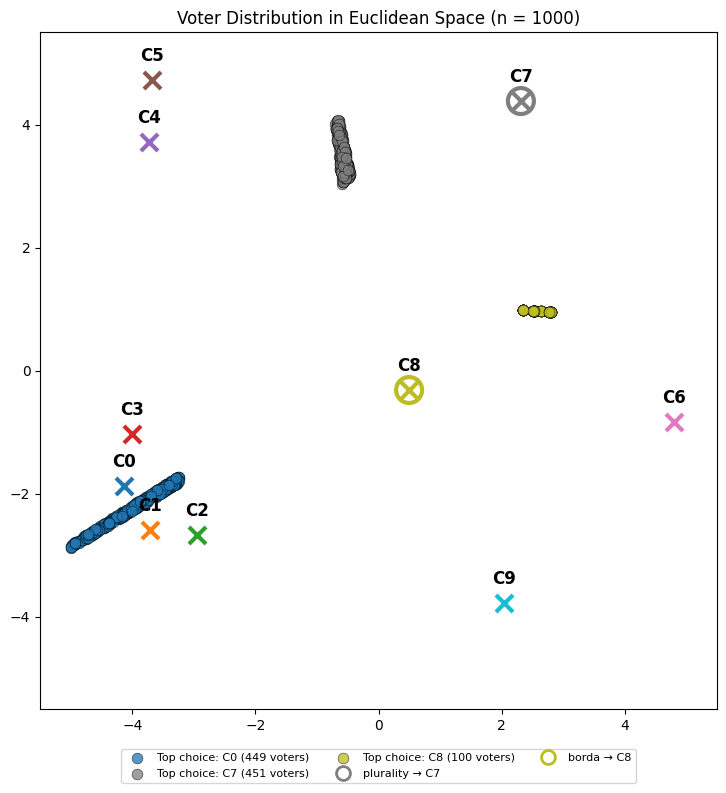

voters: 1000

rule          target  actual  ok
plurality          7       7  OK
borda              8       8  OK

All winners match — LP model is correct.


In [39]:
winners = {s.key: candidates.index(election_result.winner(s)) for s in strategies}
idxs = find_farthest_pair([candidate.position for candidate in candidates])

model = PermutationLpModel(candidates=candidates, n_voters=N_VOTERS, winners=winners)
model_result = model.solve()
assert model_result == "Optimal"

# Generate the voter positions once and reuse them for both the plot and the verification.
voter_positions = model.generate_voter_positions()
plot_lp_result(candidates, voter_positions, winners)

verify_lp_winners(voter_positions, candidates, strategies, winners)

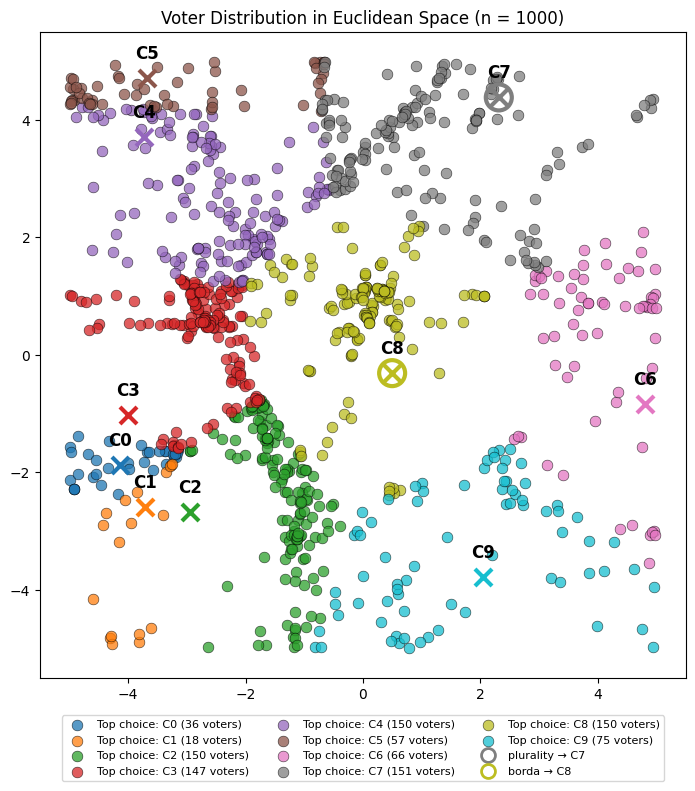

voters: 1000

rule          target  actual  ok
plurality          7       7  OK
borda              8       8  OK

All winners match — LP model is correct.


In [40]:
model = PermutationLpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="minmax"
)
model_result = model.solve()
assert model_result == "Optimal"

# Generate the voter positions once and reuse them for both the plot and the verification.
voter_positions = model.generate_voter_positions()
plot_lp_result(candidates, voter_positions, winners)

verify_lp_winners(voter_positions, candidates, strategies, winners)

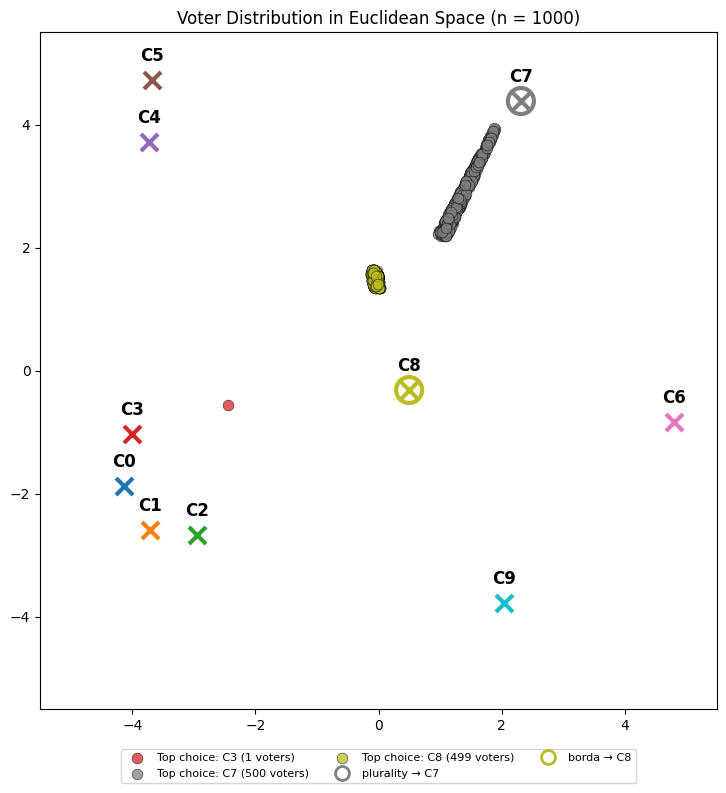

voters: 1000

rule          target  actual  ok
plurality          7       7  OK
borda              8       8  OK

All winners match — LP model is correct.


In [41]:
model = PermutationLpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="maxmin"
)
model_result = model.solve()
assert model_result == "Optimal"

# Generate the voter positions once and reuse them for both the plot and the verification.
voter_positions = model.generate_voter_positions()
plot_lp_result(candidates, voter_positions, winners)

verify_lp_winners(voter_positions, candidates, strategies, winners)

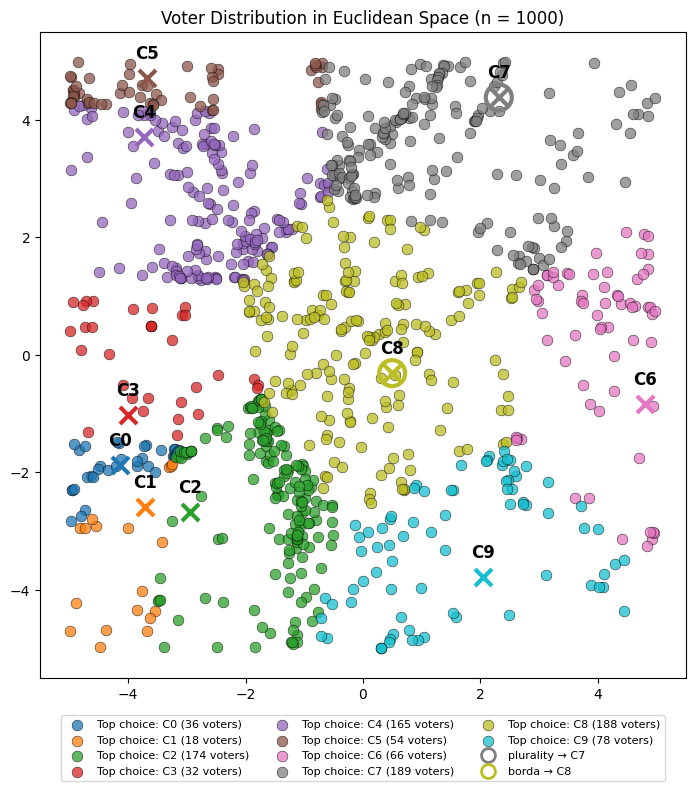

voters: 1000

rule          target  actual  ok
plurality          7       7  OK
borda              8       8  OK

All winners match — LP model is correct.


In [42]:
model = PermutationLpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="range"
)
model_result = model.solve()
assert model_result == "Optimal"

# Generate the voter positions once and reuse them for both the plot and the verification.
voter_positions = model.generate_voter_positions()
plot_lp_result(candidates, voter_positions, winners)

verify_lp_winners(voter_positions, candidates, strategies, winners)

# 4.

In [43]:
N_VOTERS = 1000
N_CANDIDATES = 4

winners = {}
candidates = []

for _ in range(100):
    candidates = [
        Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)
    ]
    idxs = find_farthest_pair([candidate.position for candidate in candidates])

    winners = {
        "plurality": idxs[0],
        "borda": idxs[1],
    }

    model = PermutationLpModel(
        candidates=candidates, n_voters=N_VOTERS, winners=winners
    )

    if model.solve() == "Optimal":
        break

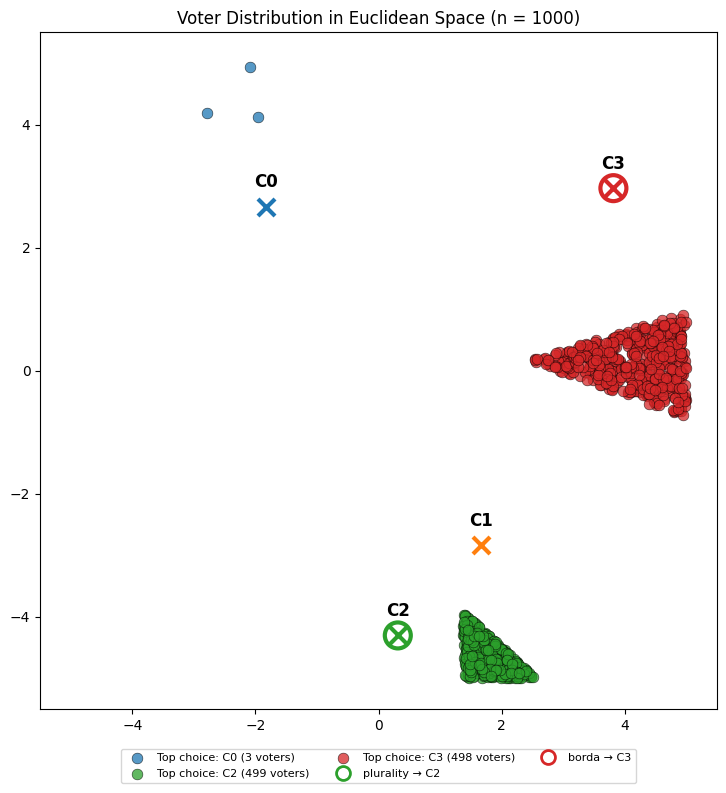

voters: 1000

rule          target  actual  ok
plurality          2       2  OK
borda              3       3  OK

All winners match — LP model is correct.


In [44]:
# Generate the voter positions once and reuse them for both the plot and the verification.
voter_positions = model.generate_voter_positions()
plot_lp_result(candidates, voter_positions, winners)

verify_lp_winners(voter_positions, candidates, strategies, winners)

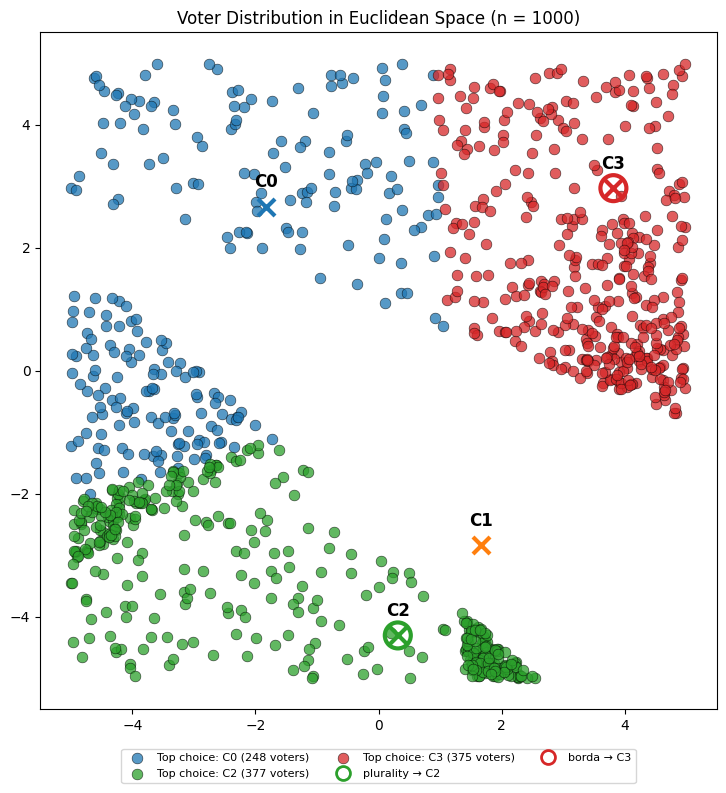

voters: 1000

rule          target  actual  ok
plurality          2       2  OK
borda              3       3  OK

All winners match — LP model is correct.


In [45]:
model = PermutationLpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="minmax"
)
model_result = model.solve()
assert model_result == "Optimal"

# Generate the voter positions once and reuse them for both the plot and the verification.
voter_positions = model.generate_voter_positions()
plot_lp_result(candidates, voter_positions, winners)

verify_lp_winners(voter_positions, candidates, strategies, winners)

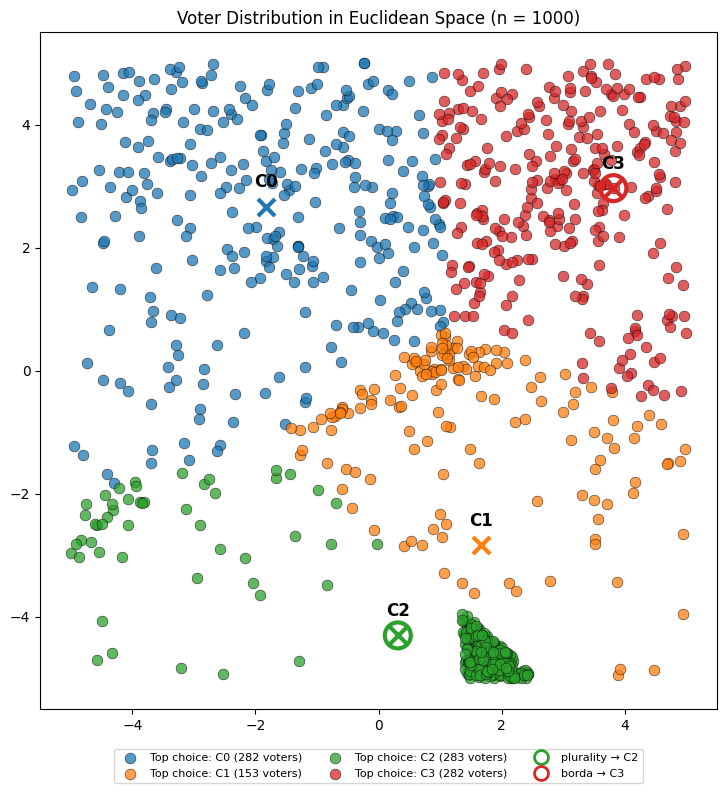

voters: 1000

rule          target  actual  ok
plurality          2       2  OK
borda              3       3  OK

All winners match — LP model is correct.


In [46]:
model = PermutationLpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="maxmin"
)
model_result = model.solve()
assert model_result == "Optimal"

# Generate the voter positions once and reuse them for both the plot and the verification.
voter_positions = model.generate_voter_positions()
plot_lp_result(candidates, voter_positions, winners)

verify_lp_winners(voter_positions, candidates, strategies, winners)

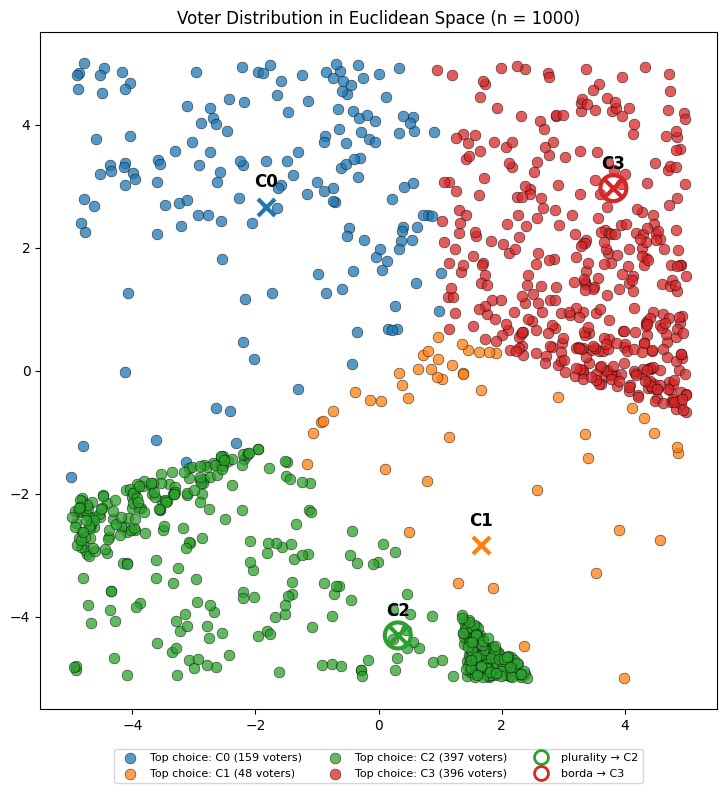

voters: 1000

rule          target  actual  ok
plurality          2       2  OK
borda              3       3  OK

All winners match — LP model is correct.


In [47]:
model = PermutationLpModel(
    candidates=candidates, n_voters=N_VOTERS, winners=winners, objective="range"
)
model_result = model.solve()
assert model_result == "Optimal"

# Generate the voter positions once and reuse them for both the plot and the verification.
voter_positions = model.generate_voter_positions()
plot_lp_result(candidates, voter_positions, winners)

verify_lp_winners(voter_positions, candidates, strategies, winners)